In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

In [ ]:
n = 100
nu_sq = .1
pvalues = None
for nu_sq in [0., 0.1]:
    for signal_fac in [.0, .1, .2, .3]:
        savepath = f'experiments/results/spline/spline_{n}_signal_{signal_fac}_nusq_{nu_sq}_train_2000_val_500_maxknots_5_cv_10'
        count = 0
        for seed in range(500):
            try:
                res = pd.read_csv(f'{savepath}/{seed}.csv', index_col=0)
                res = res.rename(columns={'adjusted': 'nf'})
            except:
                continue
            count += 1
            res['signal'] = signal_fac
            res['nu_sq'] = nu_sq
            if pvalues is None:
                pvalues = res
            else:
                pvalues = pd.concat([pvalues, res], axis=0)
        print('signal_fac:', signal_fac, 'total:', count)

signal_fac: 0.0 total: 500
signal_fac: 0.1 total: 500
signal_fac: 0.2 total: 500
signal_fac: 0.3 total: 500
signal_fac: 0.0 total: 500
signal_fac: 0.1 total: 500
signal_fac: 0.2 total: 500
signal_fac: 0.3 total: 500


In [7]:
df = pvalues.melt(id_vars=['signal', 'nu_sq'], var_name='method', value_name='pvalue')
df['reject'] = (df['pvalue'] < 0.05)

color_list = {
    'naive': '#999999',
    'nf': '#31a354',
    'splitting': '#756bb1'
}

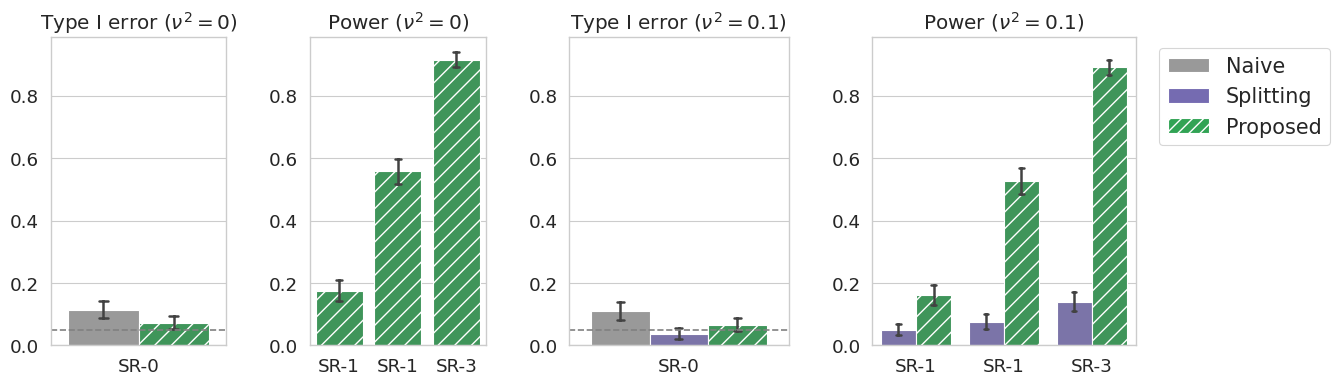

In [ ]:
sns.set_theme(context='paper', style='whitegrid', font_scale=1.5)
fig = plt.figure(figsize=(14, 4))  # width x height in inches
widths = [2, 2, 2.5, 3]  # relative widths of the 4 subplots

gs = gridspec.GridSpec(1, 4, width_ratios=widths, wspace=0.4)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharey=ax1)    
ax3 = fig.add_subplot(gs[2], sharey=ax1)
ax4 = fig.add_subplot(gs[3], sharey=ax1)
axes = [ax1, ax2, ax3, ax4]

sns.barplot(ax=ax1, data=df[(df['nu_sq'] == 0.) & (df['signal'] == 0.) & (df['method'].isin(['naive', 'nf']))], x='signal', y='reject', hue='method', capsize=.1, palette=color_list)
ax1.axhline(0.05, ls='--', c='grey')
ax1.set_title(r'Type I error ($\nu^2=0$)')
bars = ax1.patches
bars[1].set_hatch('//')
ax1.set_xticks([0], ['SR-0'])

sns.barplot(ax=ax2, data=df[(df['nu_sq'] == 0.) & (df['signal'] > 0.) & (df['method'] == 'nf')], x='signal', y='reject', hue='method', capsize=.1, palette=color_list)
ax2.set_title(r'Power ($\nu^2=0$)')
bars = ax2.patches
bars[0].set_hatch('//')
bars[1].set_hatch('//')
bars[2].set_hatch('//')
ax2.set_xticks([0, 1, 2], ['SR-1', 'SR-1', 'SR-3'])

sns.barplot(ax=ax3, data=df[(df['nu_sq'] == 0.1) & (df['signal'] == 0.)], x='signal', y='reject', hue='method', hue_order=['naive', 'splitting', 'nf'], capsize=.1, palette=color_list)
ax3.axhline(0.05, ls='--', c='grey')
ax3.set_title(r'Type I error ($\nu^2=0.1$)')
bars = ax3.patches
bars[2].set_hatch('//')
ax3.set_xticks([0], ['SR-0'])

sns.barplot(ax=ax4, data=df[(df['nu_sq'] == 0.1) & (df['signal'] > 0.) & (df['method'].isin(['nf', 'splitting']))], x='signal', y='reject', hue='method', hue_order=['splitting', 'nf'], capsize=.1, palette=color_list)
ax4.set_title(r'Power ($\nu^2=0.1$)')
bars = ax4.patches
bars[3].set_hatch('//')
bars[4].set_hatch('//')
bars[5].set_hatch('//')
ax4.set_xticks([0, 1, 2], ['SR-1', 'SR-1', 'SR-3'])

for ax in axes:
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.legend().remove()

labels = ['Naive', 'Splitting', 'Proposed']
colors = {
    'Naive': '#999999',
    'Proposed': '#31a354',
    'Splitting': '#756bb1'
}
hatches = {
    'Naive': '',
    'Proposed': '///',
    'Splitting': ''
}

legend_patches = [
    Patch(facecolor=colors[m], hatch=hatches[m], edgecolor=None, label=m)
    for m in labels
]

plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=15)
